In [1]:
from platform import python_version
print(python_version())

3.11.14


### Calculating DEGs statistics

### For each LFC/FDR cutoff set, we get a different set of DEGs
  - LFC: LFC cutoff and FDR_LFC cutoff
  - Pathway: fdr and pval pathway cutoff and min num of genes

### Up and Down DEGs simulation
  - Up and Down DEGs/DAPs
  - Up and Down in pathways

### there are 2 statistical tables
  - pval/fdr cutoff x degs
  - pval/fdr/geneset/quantile degs_in_pathway, num_pathways

In [2]:
import os, sys, yaml
from pathlib import Path
from dotenv import load_dotenv

import numpy as np
import pandas as pd
pd.set_option('display.width', 100)
pd.set_option('max_colwidth', 80)
pd.set_option("display.precision", 3)

import seaborn as sns
sns.set_context("notebook", font_scale=1.4)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

sys.path.insert(1, '../src/')

ROOT0 = Path("/home/flavio/uv/perturb_agent/")
ROOT_SRC = ROOT0 / "src"

if str(ROOT_SRC) not in sys.path:
    sys.path.append(str(ROOT_SRC))

print("ROOT0:", ROOT0)
print("ROOT_SRC added:", ROOT_SRC)

from libs.Basic import *
from libs.MTD_lib import MTD
from libs.cBioPortal_lib import cBioPortal
from libs.calc_degs_lib import CALC_DEGS
# from libs.dashcyto_lib import DASH_CYTO
from libs.config_lib import Config

from IPython.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))

with open('../params.yml', 'r') as file:
    dic_yml = yaml.safe_load(file)

# print(dic_yml)

ROOT0: /home/flavio/uv/perturb_agent
ROOT_SRC added: /home/flavio/uv/perturb_agent/src


/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/Bio/__init__.py:138: BiopythonWarning: You may be importing Biopython from inside the source tree. This is bad practice and might lead to downstream issues. In particular, you might encounter ImportErrors due to missing compiled C extensions. We recommend that you try running your code from outside the source tree. If you are outside the source tree then you have a pyproject.toml file in an unexpected directory: /home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages
  warnings.warn(
/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
email = os.getenv('email')

i_project=0

project_list = dic_yml['project_list']
n = len(project_list)
project = project_list[i_project]

s_project_list = dic_yml['s_project_list']
s_project = s_project_list[i_project]
assert n==len(project_list), f"Error project_list: there are {n} projects"

PROG_ID = 'TCGA'
PSI_ID = 'TCGA-BRCA'
PSI_ID = 'TCGA-ACC'
PSI_ID = 'TCGA-CESC'
PSI_ID = 'TCGA-PAAD'

ROOT0_DATA = ROOT0 / "data"
root_colab = ROOT0_DATA / 'colab'
root_project = ROOT0_DATA / PROG_ID

disease = PSI_ID

root_project = create_dir(ROOT0_DATA, s_project)
root_disease = create_dir(root_project, PSI_ID)

CONTEXT_DISESE = 'xxxx'
context_disease = CONTEXT_DISESE

gene_protein = dic_yml['gene_protein']
s_omics = dic_yml['s_omics']

has_age = dic_yml['has_age']
has_gender = dic_yml['has_gender']

exp_normalization = dic_yml['exp_normalization']
normalization = 'quantile_norm' if exp_normalization == True else 'not_normalized'

LFC_cut_inf = dic_yml['LFC_cut_inf']
s_pathw_enrichm_method = dic_yml['s_pathw_enrichm_method']
ptw_min_num_of_degs_cut = dic_yml['ptw_min_num_of_degs_cut']

tolerance_pPMI = dic_yml['tolerance_pPMI']
type_sat_ptw_index = dic_yml['type_sat_ptw_index']
saturation_lfc_param = dic_yml['saturation_lfc_param']

pval_pathway_cutoff = dic_yml['pval_pathway_cutoff']
fdr_pathway_cutoff = dic_yml['fdr_pathway_cutoff']
num_of_genes_cutoff = dic_yml['num_of_genes_cutoff']
enr_db_list = dic_yml['enr_db_list']


case_list = dic_yml['case_list']
dic_case_list = dic_yml['dic_case_list']

std_filename      = dic_yml['std_filename']
std_filename_list = dic_yml['std_filename_list']

min_lfc_modulation = dic_yml['min_lfc_modulation']
num_of_genes_list  = dic_yml['num_of_genes_list']
pPMI_normalized  = dic_yml['pPMI_normalized']

#--- max len for formatting purposes
s_len_case  = dic_yml['s_len_case']

n_sentences = dic_yml['n_sentences']
run_list = dic_yml['run_list']
chosen_model_list = dic_yml['chosen_model_list']
i_dfp_list = dic_yml['i_dfp_list']
chosen_model_sampling = dic_yml['chosen_model_sampling']

fdr_ptw_cutoff_list = np.arange(0.05, 0.80, 0.05)
lfc_list = np.round(np.arange(1.0, -0.01, -.025), 3)
fdr_list = np.arange(0.05, 0.76, .01)

cfg = Config(root0=ROOT0, root_disease=root_disease, disease=disease, case_list=case_list)
case = case_list[0]

n_genes_annot_ptw, n_degs, n_degs_in_ptw, n_degs_not_in_ptw, degs_in_all_ratio = -1,-1,-1,-1,-1

LFC_cut, lfc_FDR_cut, n_degs, n_degs_up, n_degs_dw = cfg.get_best_lfc_cutoff(case, 'not_normalized')

print(f"project '{project}', s_project '{s_project}'")
print(f"G/P LFC cutoffs: lfc={LFC_cut:.3f}; fdr={lfc_FDR_cut:.3f} - LFC_cut_inf={LFC_cut_inf:.3f}")
print(f"Pathway cutoffs: pval={pval_pathway_cutoff:.3f}; fdr={fdr_pathway_cutoff:.3f}; num of genes={num_of_genes_cutoff}")

Best parameter file for LFC does not exist /home/flavio/uv/perturb_agent/data/TCGA/TCGA-PAAD/config/all_lfc_cutoffs_TCGA-PAAD.tsv
project 'TCGA', s_project 'TCGA'
G/P LFC cutoffs: lfc=1.000; fdr=0.050 - LFC_cut_inf=0.400
Pathway cutoffs: pval=0.050; fdr=0.050; num of genes=3


In [4]:
mtd = MTD(disease=disease, gene_protein=gene_protein, s_omics=s_omics, project=project, s_project=s_project, 
          root0=ROOT0, root0_data=ROOT0_DATA, prog_id=PROG_ID, psi_id=PSI_ID,
          case_list=case_list, dic_case_list=dic_case_list, has_age=has_age, has_gender=has_gender, exp_normalization=exp_normalization,
          std_filename=std_filename, std_filename_list=std_filename_list,
          geneset_num=0, ptw_min_num_of_degs_cut=ptw_min_num_of_degs_cut,
          tolerance_pPMI=tolerance_pPMI, s_pathw_enrichm_method=s_pathw_enrichm_method,
          LFC_cut_inf=LFC_cut_inf, fdr_ptw_cutoff_list=fdr_ptw_cutoff_list,
          num_of_genes_list=num_of_genes_list, lfc_list=lfc_list, fdr_list=fdr_list, 
          min_lfc_modulation=min_lfc_modulation, type_sat_ptw_index=type_sat_ptw_index,
          saturation_lfc_param=saturation_lfc_param, enr_db_list=enr_db_list, pPMI_normalized=pPMI_normalized)

print(">>> Roots", mtd.root0, mtd.root_disease)
case = case_list[0]
print(">>>", case)

mtd.cfg.set_default_best_lfc_cutoff(mtd.normalization, LFC_cut=1, lfc_FDR_cut=0.05)
ret, degs, degs_ensembl, dfdegs = mtd.open_case(case, prompt_verbose=True, verbose=False)
print("\nEcho Parameters:")
print(mtd.echo_parameters())

>>> Roots /home/flavio/uv/perturb_agent /home/flavio/uv/perturb_agent/data/TCGA/TCGA-PAAD
>>> Tumor
>>> case Tumor
	DEGs 20484
		Up (#12140)
		Dw (#8344)

Up-regulated per biotype
                               biotype     n
0                            IG_C_gene    13
1                      IG_C_pseudogene     3
2                            IG_J_gene     9
3                      IG_J_pseudogene     1
4                            IG_V_gene   127
5                      IG_V_pseudogene    48
6                              Mt_tRNA    17
7                                  TEC   148
8                            TR_C_gene     6
9                            TR_D_gene     1
10                           TR_J_gene     8
11                           TR_V_gene    45
12                     TR_V_pseudogene     4
13                              lncRNA  4162
14                               miRNA   139
15                            misc_RNA    36
16              polymorphic_pseudogene     4
17        

In [5]:
cbio = cBioPortal(root0=ROOT0, root0_data=ROOT0_DATA, memory_restriction=False)

### Get all programs

In [6]:
verbose = False

df_psi = cbio.open_primary_site(verbose=verbose)
df_psi

,prog_id,cbioportal_study_id,active,gdc_project_id,psi_id,disease_id,disease_cd,primary_site,disease_context
0,TCGA,paad_tcga_pan_can_atlas_2018,True,TCGA-PAAD,PAAD,pancreatic_adenocarcinoma,PAAD,Pancreas,"TCGA pancreatic adenocarcinoma, PanCancer Atlas"
1,CPTAC3,paad_cptac_2021,True,CPTAC-3,PAAD,pancreatic_ductal_adenocarcinoma,PAAD,Pancreas,"CPTAC publication cohort, Cell 2021; 140 pancreatic cancers"
2,TCGA,skcm_tcga_pan_can_atlas_2018,True,TCGA-SKCM,SKCM,cutaneous_melanoma,SKCM,Skin,"TCGA skin cutaneous melanoma, PanCancer Atlas"
3,TCGA,brca_tcga_pan_can_atlas_2018,True,TCGA-BRCA,BRCA,breast_invasive_carcinoma,BRCA,Breast,"TCGA breast invasive carcinoma, PanCancer Atlas"
4,CPTAC2,brca_cptac_2020,True,CPTAC-2,BRCA,breast_cancer,BRCA,Breast,"CPTAC breast cancer publication cohort, Cell 2020"


### Open primary cites from cbio

In [7]:
PROG_ID = 'TCGA'
psi_id = 'PAAD'
psi_id = 'SKCM'
psi_id = 'BRCA'

PROG_ID = 'CPTAC2'
psi_id = 'BRCA'

PROG_ID = 'CPTAC3'
psi_id = 'PAAD'


verbose=True
cbio.set_program_and_primary_site(prog_id=PROG_ID, psi_id=psi_id, verbose=verbose)


-----------------------------
>> prog_id: CPTAC3
>> psi_id: PAAD
>> primary_site: Pancreas
>> disease_id: pancreatic_ductal_adenocarcinoma
>> disease_cd: PAAD

-----------------------------
>> cbioportal_study_id: paad_cptac_2021
>> gdc_project_id: CPTAC-3

-----------------------------
>> root disease: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD
>> root samples: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/samples
>> root lfc: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/lfc
>> root mutations: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/mutations
-----------------------------



,prog_id,cbioportal_study_id,active,gdc_project_id,psi_id,disease_id,disease_cd,primary_site,disease_context
1,CPTAC3,paad_cptac_2021,True,CPTAC-3,PAAD,pancreatic_ductal_adenocarcinoma,PAAD,Pancreas,"CPTAC publication cohort, Cell 2021; 140 pancreatic cancers"


### Calc expression

 - calc_file_expression_tumor_normal_gtex()
   - get_dic_expression_tumor_and_normal()
     - get_filtered_tables()
     - get_table_given_fileID()
   - prepare_normal_tumor_tables()

  
#### Tables in: root_disease / lfc

In [8]:
cbio.root_disease, cbio.root_lfc, cbio.filename_demo

(PosixPath('/home/flavio/uv/perturb_agent/data/CPTAC3/PAAD'),
 PosixPath('/home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/lfc'),
 PosixPath('/home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/clinical_and_demographics_for_paad_cptac_2021.tsv'))

### Get cases, subtypes and clin_demo tables

In [9]:
verbose=False
force=False

PROG_ID = 'TCGA'
psi_id = 'SKCM'
psi_id = 'BRCA'
psi_id = 'PAAD'

PROG_ID = 'CPTAC2'
psi_id = 'BRCA'

PROG_ID = 'CPTAC3'
psi_id = 'PAAD'

cbio.set_program_and_primary_site(prog_id=PROG_ID, psi_id=psi_id, verbose=verbose)

df_cases, df_subt, df_clin_demo, df_case_bar = cbio.get_cases_and_subtypes(batch_size=200, force=force, verbose=verbose)

df_cases.shape, df_clin_demo.shape, df_case_bar.shape

((170, 27), (140, 20), (140, 2))

In [10]:
verbose=False
force=False

imax_tumor=200
imax_normal=100

df_tumor, df_normal, df_gtex_ctrl = cbio.calc_file_expression_tumor_normal_gtex(
            imax_tumor=imax_tumor, imax_normal=imax_normal, force=force, verbose=verbose)

print(df_tumor.shape[1], df_normal.shape[1], df_gtex_ctrl.shape[1])

There are 49 tumor and 20 normal Gene Expression tables
>> prepare_normal_tumor_tables()
>>> Processing normal data: 20
>>> Processing tumor data: 49
Error: could not find GTEx ID for CPTAC3 ID 'CPTAC3 - PAAD'
52 23 0


In [11]:
df_tumor.head(3)

,geneid,symbol,biotype,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,...,T-C3L-03632,T-C3N-02589,T-C3N-03006,T-C3N-02996,T-C3N-03754,T-C3L-03639,T-C3L-02606,T-C3N-03665,T-C3N-03173,T-C3N-02696
0,ENSG00000000003,TSPAN6,protein_coding,2,2,0,0,1,1,1,...,0,0,0,0,1,0,0,0,2,1
1,ENSG00000000005,TNMD,protein_coding,12,10,14,1,12,2,5,...,9,6,10,11,14,31,5,1,6,6
2,ENSG00000000419,DPM1,protein_coding,9,9,4,9,13,5,7,...,8,8,10,10,8,2,1,0,9,16


In [12]:
df_normal.head(3)

,geneid,symbol,biotype,N-C3L-04072,N-C3L-00589,N-C3L-03123,N-C3L-04080,N-C3L-00640,N-C3N-01719,N-C3L-07033,...,N-C3N-01899,N-C3N-00517,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696
0,ENSG00000000003,TSPAN6,protein_coding,0,0,0,0,0,0,3,...,1,0,0,1,2,2,0,1,0,0
1,ENSG00000000005,TNMD,protein_coding,7,19,4,22,8,5,4,...,10,31,5,8,7,15,2,5,13,9
2,ENSG00000000419,DPM1,protein_coding,13,11,3,5,9,11,17,...,3,7,6,5,10,13,5,1,9,5


In [13]:
df_gtex_ctrl.head(3)

""


### Data treatment

1. get raw dfc
2. filter low-expression genes
3. normalize for library size
4. variance-stabilizing transformation
5. select most variable genes
6. cluster samples into k = 3..8 groups
7. evaluate clusters
8. find gene signatures for each cluster

A low-expression gene can be biologically important and even differentially expressed, especially if it is a transcription factor, cytokine, receptor, lncRNA, or rare-cell marker.

But for unsupervised tumor clustering, we usually do not want thousands of genes with mostly zero/very low counts because they add noise and unstable distances.

In [14]:
verbose=False
force=False

imax_tumor=250
imax_normal=50

exclude_prog_list=['CCLE']
disease_cd = 'PAAD'

dfn_tumor, dfn_normal, df_gtex, df_summ = cbio.get_all_data_from_disease(disease_cd=disease_cd, 
                                                           imax_tumor=imax_tumor, imax_normal=imax_normal,
                                                           exclude_prog_list=exclude_prog_list,
                                                           force=force, verbose=verbose)
print("\n")
print(">> dfn_tumor", dfn_tumor.shape)
print(">> dfn_normal", dfn_normal.shape)

Error reading csv/tsv '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/expression_gtex_controls_counts.tsv': No columns to parse from file


>> dfn_tumor (60616, 134)
>> dfn_normal (60616, 24)


In [15]:
cbio.df_metadata

,condition,dataset,condition_numeric
cols,,,
T-C3L-02890,tumor,PAAD,1.0
T-C3L-03635,tumor,PAAD,1.0
T-C3L-02701,tumor,PAAD,1.0
T-C3L-04072,tumor,PAAD,1.0
T-C3L-00589,tumor,PAAD,1.0
...,...,...,...
N-C3N-02996,normal,PAAD,0.0
N-C3L-02606,normal,PAAD,0.0
N-C3N-03173,normal,PAAD,0.0


In [16]:
print(pd.crosstab(cbio.df_metadata["dataset"], cbio.df_metadata["condition"]))

condition  normal  tumor
dataset                 
PAAD           21    131


### Batch effect correction and cpm normalization

In [17]:
force=True
verbose=False

perc_min_samples=0.25; top_n=10_000

df_sel, df_cpm, df_gene_annot = cbio.calc_expression_and_batch(dfn_tumor=dfn_tumor, group='Tumor', 
                                                           perc_min_samples=perc_min_samples, top_n=top_n,
                                                           force=force, verbose=verbose)

dfn, df_gene_annot = cbio.calc_cpm_merge_turmor_and_normal(dfn_tumor=dfn_tumor, dfn_normal=dfn_normal, 
                                                                   perc_min_samples=perc_min_samples, top_n=top_n,
                                                                   verbose=verbose)

dfall = cbio.dfall
print(dfn.shape, dfall.shape)
dfall.tail(3)

Transforming expression data for group: Tumor ...
sample_cols 131 and min_samples
(10000, 152) (25146, 155)


,geneid,symbol,biotype,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,...,N-C3N-00517,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-A45N
25143,ENSG00000288663,AC073611.1,lncRNA,1.572,0.833,0.849,0.851,0.786,1.397,1.840,...,1.808,1.501,1.382,1.185,1.174,2.545,1.870,1.592,1.507,1.288
25144,ENSG00000288670,AL592295.6,lncRNA,0.000,0.000,0.486,0.000,0.786,1.063,0.600,...,0.441,0.000,0.000,0.000,0.505,0.000,0.000,0.000,0.546,2.282
25145,ENSG00000288675,AP006621.6,protein_coding,3.494,2.174,1.928,2.076,2.513,1.669,2.205,...,2.822,3.583,2.402,0.886,1.629,1.912,3.483,2.468,2.601,1.194


In [18]:
dfall.head(3).T

,0,1,2
geneid,ENSG00000000003,ENSG00000000005,ENSG00000000419
symbol,TSPAN6,TNMD,DPM1
biotype,protein_coding,protein_coding,protein_coding
T-C3L-02890,0.84,2.52,2.187
T-C3L-03635,0.833,2.294,2.174
...,...,...,...
N-C3N-02996,0.0,1.252,2.155
N-C3L-02606,0.529,1.684,0.529
N-C3N-03173,0.0,2.916,2.468
N-C3N-02696,0.0,2.363,1.723


In [19]:
dfn.head(3)

,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,N-C3N-00517,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-A45N
geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000270641,2.520,2.174,2.072,0.488,3.477,14.041,12.768,14.021,14.081,13.499,...,14.191,14.616,5.340,14.794,3.787,14.231,14.426,6.388,2.994,10.485
ENSG00000280109,9.525,10.096,10.137,8.915,10.880,10.323,10.818,10.756,11.655,9.504,...,10.672,10.481,10.511,12.285,10.846,9.456,11.043,9.746,10.952,0.633
ENSG00000224879,13.696,2.044,3.563,8.949,11.988,4.642,9.174,5.209,4.769,3.825,...,14.297,15.369,12.817,9.867,13.192,12.033,13.961,14.393,14.264,0.000


In [20]:
dfn.shape, np.sum([1 if x.startswith('T-') else 0 for x in dfn.columns]), np.sum([1 if x.startswith('N-') else 0 for x in dfn.columns])

((10000, 152), 131, 21)

In [21]:
dfall.shape

(25146, 155)

### Batch effect correction

In [22]:
dfn_tumor.shape, dfn_normal.shape

((60616, 134), (60616, 24))

In [23]:
df_metadata = cbio.df_metadata
df_metadata.head(3)

,condition,dataset,condition_numeric
cols,,,
T-C3L-02890,tumor,PAAD,1.0
T-C3L-03635,tumor,PAAD,1.0
T-C3L-02701,tumor,PAAD,1.0


In [24]:
force=True
verbose=True

perc_min_samples=0.25; top_n=10_000

df_combat = cbio.calc_cpm_merge_turmor_and_normal_batch_correction(dfn_tumor=dfn_tumor, dfn_normal=dfn_normal,
                                                                  perc_min_samples=perc_min_samples, top_n=top_n,
                                                                  force=force, verbose=verbose)
print(df_combat.shape)
df_combat.head(3)

Table opened ((10000, 132)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/Tumor_expression_sel_log_CPM_top_10000_genes_all_samples.tsv'
Table opened ((25146, 132)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/Tumor_expression_log_CPM_all_samples.tsv'
Table opened ((10000, 3)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/Tumor_expression_gene_annot_top_10000_genes_all_samples.tsv'
Table opened ((25146, 155)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/cpm_log_all_genes_all_rows.tsv'
ComBat input: 10,000 genes × 152 samples
Removed 0 zero-variance genes.
Table saved ((10000, 155)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/combat_log_exp_tumor_and_normal.tsv'
(10000, 155)


,geneid,symbol,biotype,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,...,N-C3N-00517,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-A45N
0,ENSG00000270641,TSIX,lncRNA,2.531,2.186,2.084,0.505,3.485,14.013,12.745,...,14.174,14.598,5.353,14.776,3.805,14.214,14.409,6.397,3.014,10.480
1,ENSG00000280109,PLAC4,lncRNA,9.507,10.077,10.118,8.900,10.858,10.303,10.796,...,10.669,10.480,10.509,12.278,10.843,9.458,11.040,9.747,10.949,0.663
2,ENSG00000224879,AC011754.1,lncRNA,13.670,2.056,3.570,8.939,11.968,4.646,9.163,...,14.287,15.356,12.813,9.872,13.186,12.031,13.952,14.383,14.255,0.038


### Remove olders from control-normal

In [25]:
age_cutoff = 60
bmi_cutoff = 32

df_psi = cbio.open_primary_site(verbose=False)

df_psi = df_psi[ (df_psi.disease_cd == disease_cd) & (~pd.isnull(df_psi.primary_site)) & (~pd.isnull(df_psi.cbioportal_study_id)) ]
dfa = df_psi.groupby(['prog_id', 'psi_id', 'disease_id', 'disease_cd', 'primary_site', 'cbioportal_study_id']).size().reset_index()


bad_list = []

for i, row in dfa.iterrows():

    _ = cbio.set_program_and_primary_site(prog_id=row.prog_id, psi_id=row.psi_id)

    fname_demo = cbio.fname_demo0 % row.cbioportal_study_id
    filename_demo = cbio.root_disease / cbio.fname_demo

    print(i, row.psi_id, cbio.psi_id, row.cbioportal_study_id, "-->", filename_demo)


    if not filename_demo.exists():
        print(f"Could not find demo for {filename_demo}")
        continue

    df_demo = pdreadcsv(fname_demo, cbio.root_disease, verbose=True)


    df_bad = df_demo[ (df_demo.age >= age_cutoff) | (df_demo.bmi >= bmi_cutoff) ]

    df_bad = ['N-'+x for x in df_bad.barcode_case]

    bad_list += df_bad


print(len(bad_list))
bad_list



0 PAAD PAAD paad_cptac_2021 --> /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/clinical_and_demographics_for_paad_cptac_2021.tsv
Table opened ((140, 20)) at '/home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/clinical_and_demographics_for_paad_cptac_2021.tsv'
1 PAAD PAAD paad_tcga_pan_can_atlas_2018 --> /home/flavio/uv/perturb_agent/data/TCGA/PAAD/clinical_and_demographics_for_paad_tcga_pan_can_atlas_2018.tsv
Table opened ((184, 43)) at '/home/flavio/uv/perturb_agent/data/TCGA/PAAD/clinical_and_demographics_for_paad_tcga_pan_can_atlas_2018.tsv'
234


['N-C3L-00017',
 'N-C3L-00189',
 'N-C3L-00277',
 'N-C3L-00401',
 'N-C3L-00589',
 'N-C3L-00598',
 'N-C3L-00599',
 'N-C3L-00622',
 'N-C3L-00819',
 'N-C3L-00881',
 'N-C3L-00928',
 'N-C3L-01031',
 'N-C3L-01036',
 'N-C3L-01051',
 'N-C3L-01052',
 'N-C3L-01053',
 'N-C3L-01124',
 'N-C3L-01328',
 'N-C3L-01453',
 'N-C3L-01598',
 'N-C3L-01637',
 'N-C3L-01662',
 'N-C3L-01687',
 'N-C3L-01689',
 'N-C3L-01703',
 'N-C3L-01971',
 'N-C3L-02109',
 'N-C3L-02112',
 'N-C3L-02115',
 'N-C3L-02116',
 'N-C3L-02118',
 'N-C3L-02463',
 'N-C3L-02604',
 'N-C3L-02606',
 'N-C3L-02610',
 'N-C3L-02701',
 'N-C3L-02809',
 'N-C3L-02890',
 'N-C3L-02897',
 'N-C3L-02899',
 'N-C3L-03123',
 'N-C3L-03356',
 'N-C3L-03388',
 'N-C3L-03394',
 'N-C3L-03395',
 'N-C3L-03628',
 'N-C3L-03630',
 'N-C3L-03632',
 'N-C3L-03635',
 'N-C3L-03639',
 'N-C3L-03743',
 'N-C3L-04027',
 'N-C3L-04080',
 'N-C3L-04473',
 'N-C3L-04475',
 'N-C3L-04479',
 'N-C3L-04848',
 'N-C3L-04853',
 'N-C3N-00249',
 'N-C3N-00303',
 'N-C3N-00436',
 'N-C3N-00513',
 'N-C3N-

In [26]:
bad_cols = [x for x in df_combat.columns if x in bad_list]
print(len(bad_cols))
bad_cols

11


['N-C3L-00589',
 'N-C3L-03123',
 'N-C3L-04080',
 'N-C3N-01719',
 'N-C3L-00819',
 'N-C3L-01689',
 'N-C3N-00517',
 'N-C3N-02589',
 'N-C3L-02606',
 'N-C3N-03173',
 'N-TCGA-H6-A45N']

In [27]:
cols = [x for x in df_combat.columns if x not in bad_cols]

have_tumor = np.sum([1 for x in cols if x.startswith('T-')])
have_normal = np.sum([1 for x in cols if x.startswith('N-')])

print(have_tumor, have_normal)

if have_normal >= 3:
    df_combat2 = df_combat[cols]
else:
    df_combat2 = df_combat

print(df_combat2.shape)
df_combat2

131 10
(10000, 144)


,geneid,symbol,biotype,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,...,N-C3L-04072,N-C3L-00640,N-C3L-07033,N-C3L-07032,N-C3N-01899,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02996,N-C3N-02696
0,ENSG00000270641,TSIX,lncRNA,2.531,2.186,2.084,0.505,3.485,14.013,12.745,...,3.707,14.233,5.365,4.442,14.471,14.598,5.353,14.776,14.214,3.014
1,ENSG00000280109,PLAC4,lncRNA,9.507,10.077,10.118,8.900,10.858,10.303,10.796,...,11.482,9.803,10.707,10.296,10.386,10.480,10.509,12.278,9.458,10.949
2,ENSG00000224879,AC011754.1,lncRNA,13.670,2.056,3.570,8.939,11.968,4.646,9.163,...,15.024,6.789,10.184,10.446,5.531,15.356,12.813,9.872,12.031,14.255
3,ENSG00000175535,PNLIP,protein_coding,2.797,0.015,0.015,1.393,2.691,0.015,1.625,...,8.060,0.021,12.728,13.562,0.021,11.193,9.533,13.016,9.446,5.498
4,ENSG00000091704,CPA1,protein_coding,3.220,0.489,0.500,2.084,1.501,0.640,0.613,...,6.079,0.791,10.995,11.656,0.871,7.773,6.768,11.923,6.871,4.852
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,ENSG00000125651,GTF2F1,protein_coding,3.026,2.940,2.817,3.667,2.772,2.697,3.953,...,3.760,3.025,3.860,3.848,2.556,3.031,3.063,5.370,3.275,3.467
9996,ENSG00000159860,TCAF2P1,transcribed_unprocessed_pseudogene,4.096,3.369,3.740,2.437,3.272,5.318,4.426,...,5.245,6.369,4.286,4.426,4.990,2.618,2.490,4.363,2.580,5.801
9997,ENSG00000075651,PLD1,protein_coding,2.063,0.843,1.935,2.083,1.829,1.904,2.364,...,2.798,3.861,3.358,4.132,2.341,2.029,1.510,5.693,1.803,1.737
9998,ENSG00000258171,LINC02412,lncRNA,4.470,6.099,3.695,5.498,3.687,2.557,1.838,...,4.423,4.483,2.892,4.424,4.353,3.031,0.949,5.656,3.870,5.158


### Loop all clusters

In [ ]:
imax_tumor=250
imax_normal=50
exclude_prog_list=['CCLE']
n_components = 10
n_umap_neighbors=5; min_umap_dist=0.2; umap_metric="euclidean"
method_hca="ward"; hca_criterion="maxclust"
LFC_cutoff=1; FDR_cutoff=0.05

force=False
verbose=False

group = 'Tumor'
min_clusters = 3

for n_clusters in range(3, 10+1):

    print(f"Clusters: {n_clusters}")

    fname = f'all_cluster_degs_for_{n_clusters}_clusterization.txt'
    filename = cbio.root_mprog_lfc / fname

    if filename.exists() and not force:
        print(f"\tFile {fname} already exists. Skipping.")
        continue

    # for silhouette
    max_clusters = n_clusters+2

    df_cluster, df_pca, df_umap = cbio.cluster_PCA_HCA_UMAP(df_combat2, group=group, n_clusters=n_clusters, 
                                                    n_components=n_components, min_clusters=min_clusters, max_clusters=max_clusters,
                                                    n_umap_neighbors=n_umap_neighbors, min_umap_dist=min_umap_dist, umap_metric=umap_metric,
                                                    method_hca=method_hca, hca_criterion=hca_criterion,
                                                    LFC_cutoff=LFC_cutoff, FDR_cutoff=FDR_cutoff,
                                                    force=force, verbose=verbose)
    
    max_cluster = df_hca.cluster.max()
    all_clusters_text = ''

    for nclu in range(1, max_cluster + 1):

        print(f"\tProcessing cluster {nclu}/{n_clusters}")

        '''
        df_lfc, df_lfc_ori, degs_txt, degs_first2000, degs_for_AI_analysis, msg = \
            cbio.calc_limma_inmoose(df_combat=df_combat, ncluster=nclu, disease_cd=disease_cd, 
                                    age_cutoff=60, bmi_cutoff=32,
                                    lfc_cutoff = LFC_cutoff, fdr_cutoff = FDR_cutoff,
                                    force = force, verbose = verbose )
        
        text = f"\tCluster {nclu}:\n{degs_for_AI_analysis}"

        if all_clusters_text == '':
            all_clusters_text = text
        else:
            all_clusters_text += "\n\n----------------------------------\n" + text
        print(msg, '\n----------------------------------')
        '''

    print(f"------------------- end clusterization {n_clusters}---------------")
    write_txt(all_clusters_text, fname, cbio.root_mprog_lfc)

print(f"\n------------------- end -----------------------")

Clusters: 3
	File all_cluster_degs_for_3_clusterization.txt already exists. Skipping.
Clusters: 4
	File all_cluster_degs_for_4_clusterization.txt already exists. Skipping.
Clusters: 5
	File all_cluster_degs_for_5_clusterization.txt already exists. Skipping.
Clusters: 6
	File all_cluster_degs_for_6_clusterization.txt already exists. Skipping.
Clusters: 7
	File all_cluster_degs_for_7_clusterization.txt already exists. Skipping.
Clusters: 8
	File all_cluster_degs_for_8_clusterization.txt already exists. Skipping.
Clusters: 9
	File all_cluster_degs_for_9_clusterization.txt already exists. Skipping.
Clusters: 10
	File all_cluster_degs_for_10_clusterization.txt already exists. Skipping.

------------------- end -----------------------


In [29]:
imax_tumor=250
imax_normal=50
exclude_prog_list=['CCLE']
n_components = 10
n_umap_neighbors=5; min_umap_dist=0.2; umap_metric="euclidean"
method_hca="ward"; hca_criterion="maxclust"
LFC_cutoff=1; FDR_cutoff=0.05

force=False
verbose=False

group = 'Tumor'
min_clusters = 3

n_clusters = 5

print(f"Clusters: {n_clusters}")

fname = f'all_cluster_degs_for_{n_clusters}_clusterization.txt'
filename = cbio.root_mprog_lfc / fname

# for silhouette
max_clusters = n_clusters+2

df_cluster, df_pca, df_umap = cbio.cluster_PCA_HCA_UMAP(df_combat2, group=group, n_clusters=n_clusters, 
                                                n_components=n_components, min_clusters=min_clusters, max_clusters=max_clusters,
                                                n_umap_neighbors=n_umap_neighbors, min_umap_dist=min_umap_dist, umap_metric=umap_metric,
                                                method_hca=method_hca, hca_criterion=hca_criterion,
                                                LFC_cutoff=LFC_cutoff, FDR_cutoff=FDR_cutoff,
                                                force=force, verbose=verbose)

df_hca = cbio.df_hca
df_umap =cbio.df_umap
dfall = cbio.dfall

Clusters: 5
Calc PCA ...
Calc best cluster ...
Calc PCA-UMAP ...
Find clusters' signature genes ...
Unique signature genes ...
Cluster 1: 4152 signature genes
Cluster 2: 4281 signature genes
Cluster 3: 4275 signature genes
Cluster 4: 3840 signature genes
Cluster 5: 5637 signature genes

-------------- end ------------------



In [30]:
dfall.tail(3)

,geneid,symbol,biotype,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,...,N-C3N-00517,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-A45N
25143,ENSG00000288663,AC073611.1,lncRNA,1.572,0.833,0.849,0.851,0.786,1.397,1.840,...,1.808,1.501,1.382,1.185,1.174,2.545,1.870,1.592,1.507,1.288
25144,ENSG00000288670,AL592295.6,lncRNA,0.000,0.000,0.486,0.000,0.786,1.063,0.600,...,0.441,0.000,0.000,0.000,0.505,0.000,0.000,0.000,0.546,2.282
25145,ENSG00000288675,AP006621.6,protein_coding,3.494,2.174,1.928,2.076,2.513,1.669,2.205,...,2.822,3.583,2.402,0.886,1.629,1.912,3.483,2.468,2.601,1.194


In [31]:
cbio.df_umap.tail(3)

,UMAP1,UMAP2,sample,cluster
138,15.858,6.155,N-C3L-07037,2
139,15.534,5.905,N-C3N-02996,2
140,15.012,5.546,N-C3N-02696,2


In [32]:
df_hca.tail(3)

,sample,cluster
138,N-C3L-07037,1
139,N-C3N-02996,1
140,N-C3N-02696,1


In [33]:
df_hca.cluster.unique()

array([2, 3, 5, 4, 1], dtype=int32)

### Normal clusters

In [34]:
normal_samples = df_hca[df_hca['sample'].str.startswith('N-')]
normal_samples

,sample,cluster
131,N-C3L-04072,1
132,N-C3L-00640,1
133,N-C3L-07033,1
134,N-C3L-07032,1
135,N-C3N-01899,1
136,N-C3N-03069,1
137,N-C3N-02765,1
138,N-C3L-07037,1
139,N-C3N-02996,1
140,N-C3N-02696,1


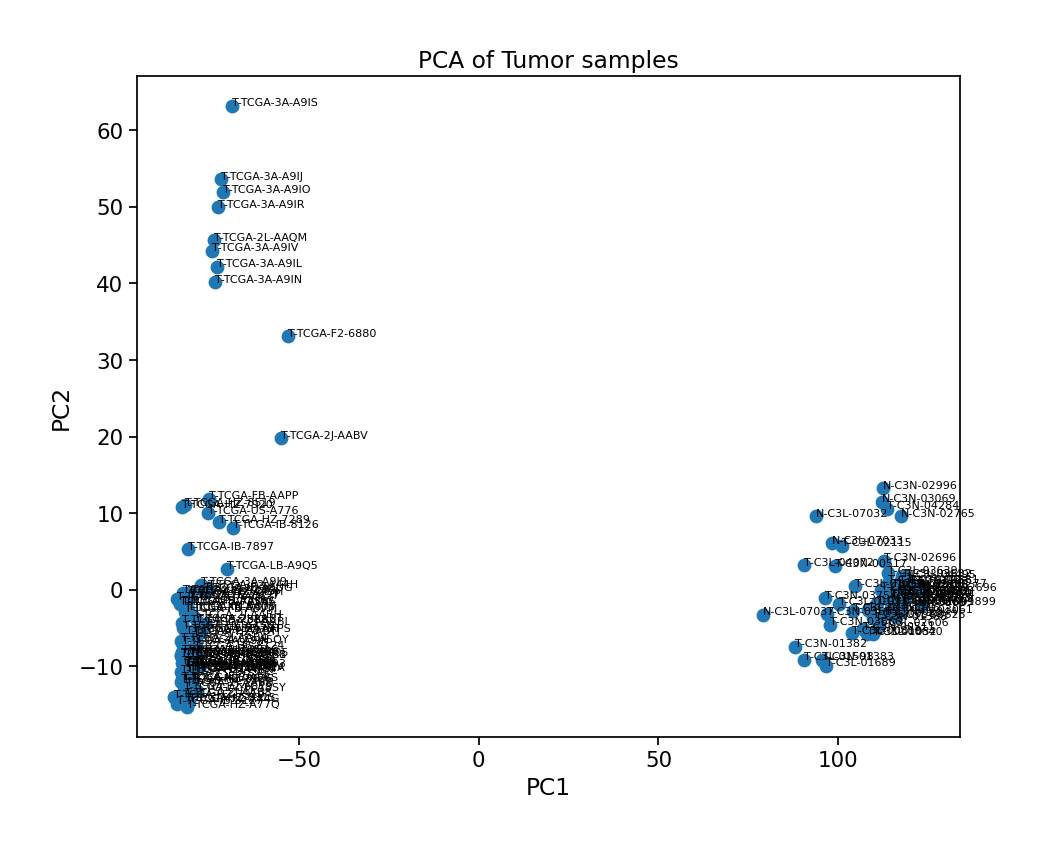

In [35]:
cbio.plot_PCA(df_pca, figsize= (10, 8))

In [36]:
df_eval, df_samp_clusters = cbio.calc_best_cluster(df_pca, min_clusters=3, max_clusters=8)
df_eval

,k,silhouette
0,3,0.741
1,4,0.653
2,5,0.619
3,6,0.601
4,7,0.385
5,8,0.431


In [37]:
df_samp_clusters.head(6)

,sample,cluster
0,T-C3L-02890,3
1,T-C3L-03635,3
2,T-C3L-02701,3
3,T-C3L-04072,3
4,T-C3L-00589,3
5,T-C3L-03123,3


### PCA-UMAP

In [38]:
df_umap2 = df_umap.set_index('sample')
df_umap2

,UMAP1,UMAP2,cluster
sample,,,
T-C3L-02890,20.482,-2.014,3
T-C3L-03635,18.546,-1.645,3
T-C3L-02701,16.433,-3.640,3
T-C3L-04072,13.248,-4.341,3
T-C3L-00589,14.722,-4.565,3
...,...,...,...
N-C3N-03069,15.498,5.908,2
N-C3N-02765,15.334,5.789,2
N-C3L-07037,15.858,6.155,2


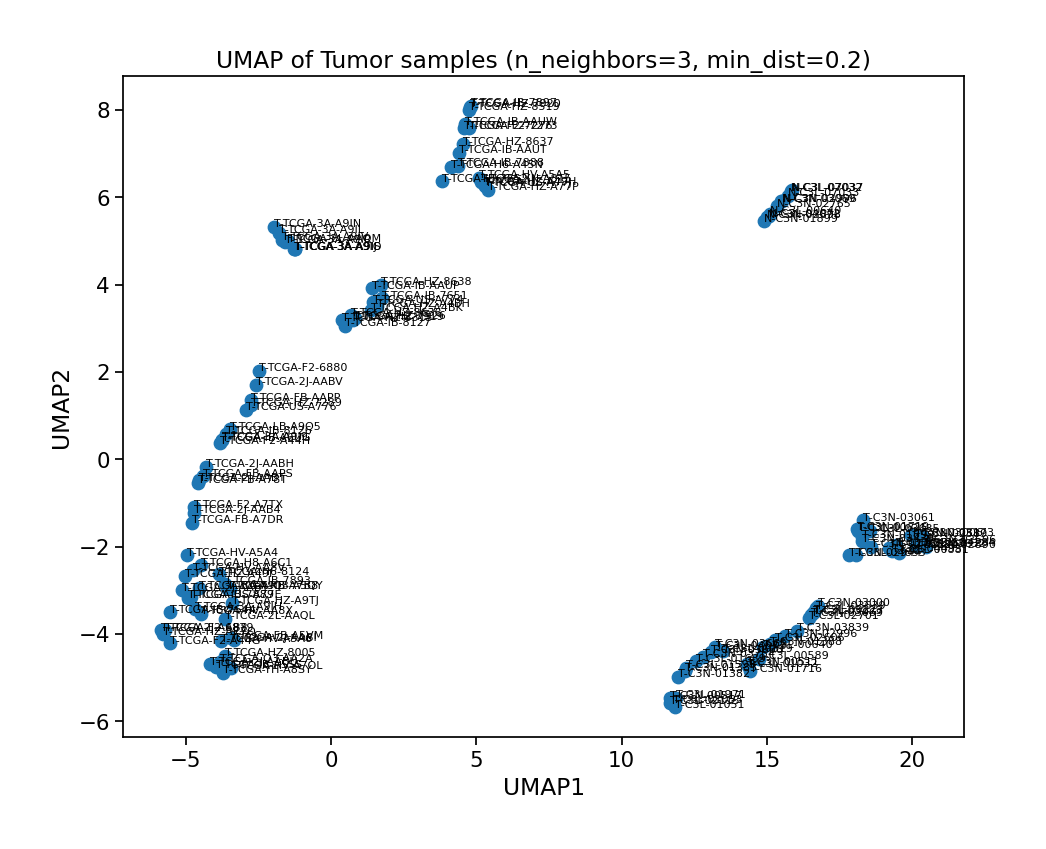

In [39]:
n_neighbors=3
min_dist=0.2

cbio.plot_PCA_UMAP(df_umap2, n_neighbors=n_neighbors, min_dist=min_dist, figsize=(10,8))

### Hierarchical clustering alternative

For 32 samples, this is often better than UMAP.

In [40]:
# Cut tree into n clusters
n_clusters=7

df_cluster_hca = cbio.cut_HCA_PCA(df_pca=df_pca, n_clusters=n_clusters, method="ward", criterion="maxclust", verbose=True)
df_cluster_hca.head(6)

cluster
1    10
2    36
3    13
4     2
5     8
6    18
7    54
dtype: int64


,sample,cluster
0,T-C3L-02890,2
1,T-C3L-03635,2
2,T-C3L-02701,2
3,T-C3L-04072,3
4,T-C3L-00589,2
5,T-C3L-03123,2


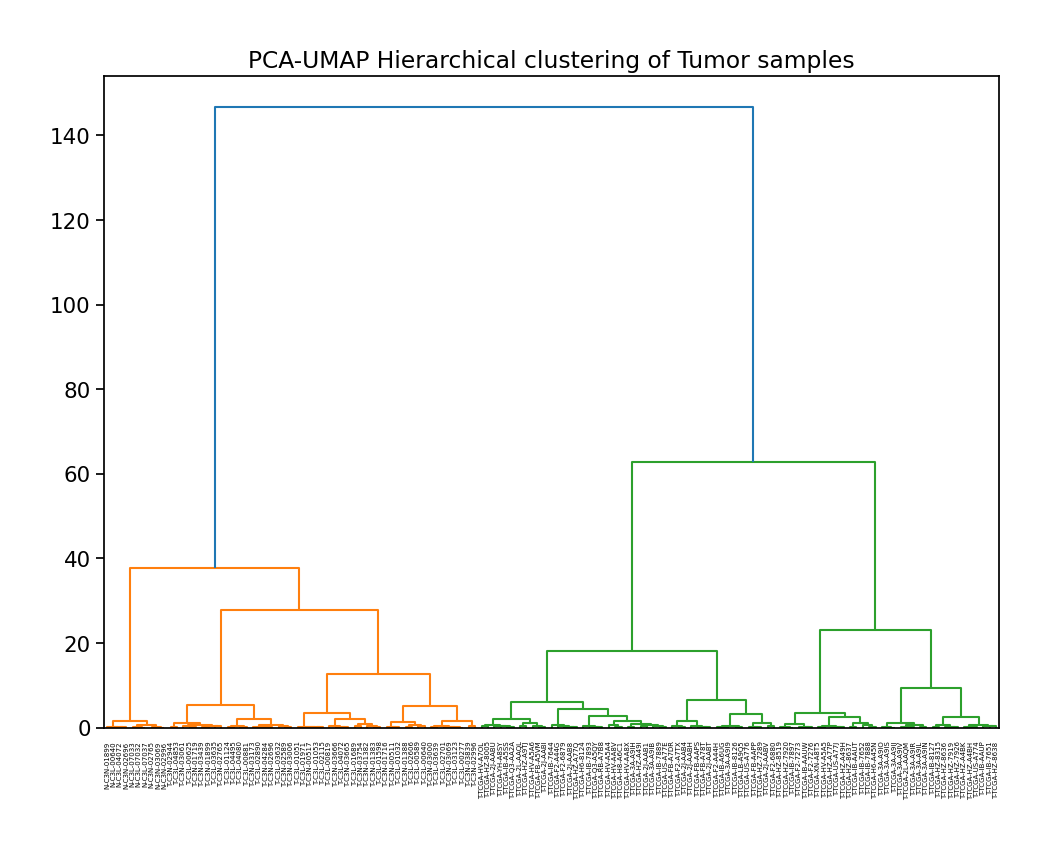

In [41]:
cbio.plot_HCA_PCA_UMAP(df_umap, figsize=(10, 8))

In [42]:
# Cut tree into k clusters

df_cluster_umap = cbio.cut_HCA_PCA_UMAP(df_umap=df_umap, n_clusters=n_clusters, method="ward", criterion="maxclust", verbose=True)
df_cluster_umap.head(6)

cluster
1    10
2    20
3    29
4    30
5    17
6    16
7    19
dtype: int64


,sample,cluster
0,T-C3L-02890,2
1,T-C3L-03635,2
2,T-C3L-02701,3
3,T-C3L-04072,3
4,T-C3L-00589,3
5,T-C3L-03123,3


### Define cluster marker genes

This finds genes high in one cluster compared with all others.

### cluster signatures

In [43]:
df_cluster

,n_clusters,ncluster,ngenes,genes,n_unique_genes,unique_genes
0,5,1,4159,"[A2M-AS1, A2ML1-AS1, A2MP1, AARSD1P1, ABALON, ABCA9-AS1, ABCC11, ABHD1, ABHD...",18,ADIPOQ-AS1; AMBP; AMY2A; CASP9; CELA2A; CELA2B; CLDN10; CLDN18; COL10A1; LIN...
1,5,2,4288,"[A2M-AS1, A2ML1-AS1, A2MP1, AARSD1P1, ABALON, ABCA9-AS1, ABCC11, ABHD1, ABHD...",12,AC000032.1; AC019349.1; AC083841.2; AL353804.7; CFAP46; JRK; KCNJ15; LINCR-0...
2,5,3,4282,"[A2M-AS1, A2ML1-AS1, A2MP1, AARSD1P1, ABALON, ABCA9-AS1, ABCC11, ABHD1, ABHD...",0,
3,5,4,3840,"[AAAS, AACS, AAGAB, AAMP, AAR2, AARS1, AARS2, AATF, ABAT, ABCA2, ABCA5, ABCA...",32,APOH; C1QL1; CALY; CAMK2B; CHGA; CPLX2; CRYBA2; DPP6; DUSP26; FOXJ1; GAD2; G...
4,5,5,5637,"[A4GALT, AAAS, AACS, AAGAB, AAMP, AAR2, AARS1, AARS2, AATF, ABAT, ABCA2, ABC...",1828,A4GALT; ABCC3; ABCC4; ABHD17C; ABHD3; ABLIM3; ABO; ABRACL; ACAP2; ACKR1; ACK...


### CALC_DEGS -> build_counts_and_metadata()

In [44]:
cdegs = CALC_DEGS(root_src=cbio.root_src, run_conda=False)
cbio.cdegs = cdegs

In [ ]:
nclu = 1

df_lfc, df_lfc_ori, degs_txt, degs_first2000, degs_for_AI_analysis, msg = \
    cbio.calc_limma_inmoose(df_combat=df_combat, ncluster=nclu, disease_cd=disease_cd, 
                            age_cutoff=60, bmi_cutoff=32,
                            lfc_cutoff = LFC_cutoff, fdr_cutoff = FDR_cutoff,
                            force = force, verbose = verbose )

No primary site information found for: TCGA-PAAD
